## 1. Setup

In [1]:
import os
import sys
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV,
    GroupKFold,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint
import xgboost as xgb

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from optilang.scoring import (
    EFFICIENCY_PATTERNS,
    MAINTAINABILITY_PATTERNS,
    QUALITY_PATTERNS,
    _density_to_score,
)


_DIMENSIONS = (
    (EFFICIENCY_PATTERNS, 15.0),
    (QUALITY_PATTERNS, 20.0),
    (MAINTAINABILITY_PATTERNS, 15.0),
)


def _weighted_density(rows, source_lines):
    if source_lines <= 0 or rows.empty:
        return 0.0

    severity = rows["severity"].map({"high": 3, "medium": 2, "low": 1}).fillna(0)
    return float(severity.sum() / source_lines)


def _dimension_score(rows, patterns, max_score):
    if rows.empty:
        return max_score

    source_lines = float(rows["source_lines"].iloc[0])
    dimension_rows = rows[rows["pattern"].isin(patterns)]
    return _density_to_score(_weighted_density(dimension_rows, source_lines), max_score)


def _score_gain_if_removed(program_rows, remove_mask):
    remaining_rows = program_rows.loc[~remove_mask]
    gain = 0.0

    for patterns, max_score in _DIMENSIONS:
        before = _dimension_score(program_rows, patterns, max_score)
        after = _dimension_score(remaining_rows, patterns, max_score)
        gain += max(0.0, after - before)

    return round(gain, 4)


def build_program_cluster_improvement_frame(rows):
    required = {"program_id", "cluster", "score", "source_lines", "pattern", "severity"}
    missing = required - set(rows.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    frame_rows = []
    numeric = rows.select_dtypes(include=[np.number]).columns
    aggregate_cols = [c for c in numeric if c != "line_number"]

    for (program_id, cluster), group in rows.groupby(["program_id", "cluster"], sort=True):
        program_rows = rows[rows["program_id"] == program_id]
        remove_mask = program_rows["cluster"].eq(cluster)
        current_score = float(program_rows["score"].iloc[0])
        score_gain = _score_gain_if_removed(program_rows, remove_mask)
        after_score = min(100.0, current_score + score_gain)

        record = {
            "program_id": program_id,
            "cluster": int(cluster),
            "cluster_suggestion_count": int(len(group)),
            "program_suggestion_count": int(len(program_rows)),
            "cluster_share": round(len(group) / len(program_rows), 6),
            "cluster_impact_sum": float(group["impact_score"].sum()),
            "cluster_impact_mean": float(group["impact_score"].mean()),
            "current_score": current_score,
            "expected_after_score": round(after_score, 4),
            "expected_score_gain_points": score_gain,
            "expected_score_improvement_pct": round(
                (score_gain / current_score) * 100.0 if current_score > 0 else 0.0,
                4,
            ),
        }

        for col in aggregate_cols:
            if col in record or col == "cluster":
                continue
            record[f"{col}_mean"] = float(group[col].mean())

        frame_rows.append(record)

    return pd.DataFrame(frame_rows)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", palette="muted")
plt.rcParams["figure.dpi"] = 120

BASE_DIR   = os.path.abspath("..")
DATA_DIR   = os.path.join(BASE_DIR, "data")
PLOTS_DIR  = os.path.join(BASE_DIR, "plots")
MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(PLOTS_DIR,  exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

RANDOM_STATE = 42
TARGET = "expected_score_improvement_pct"

## 2. Load Data and Build Program-Cluster Rows

Prediction is now trained at the correct decision level: one row per `(program_id, cluster)`.

The target is `expected_score_improvement_pct`: the expected percentage score improvement if all suggestions in that cluster are fixed for that program. It is computed by simulating removal of that cluster's suggestions from the optimizer-driven scoring dimensions.

This is not measured runtime speedup. Measured runtime improvement needs an auto-fix plus re-run stage, but the same `program_id` / `execution_id` fields added to the dataset will support that later.

In [2]:
scaled    = pd.read_csv(os.path.join(DATA_DIR, "executions_features_scaled.csv"))
clustered = pd.read_csv(os.path.join(DATA_DIR, "executions_clustered.csv"))
raw       = pd.read_csv(os.path.join(DATA_DIR, "executions.csv"))

assert len(scaled) == len(clustered) == len(raw), "Row mismatch across files"

required_ids = {"program_id", "execution_id", "suggestion_id"}
missing_ids = required_ids - set(raw.columns)
if missing_ids:
    raise ValueError(
        f"executions.csv is missing {sorted(missing_ids)}. "
        "Regenerate it with: python3 -m optilang.ml.src.runner"
    )
if "cluster" not in clustered.columns:
    raise ValueError("executions_clustered.csv is missing cluster. Re-run 02_clustering.ipynb.")

row_level = raw.copy()
row_level["cluster"] = clustered["cluster"].astype(int)

# Carry suggestion-level scaled clustering features into the cluster aggregate.
scaled_prefixed = scaled.add_prefix("scaled_")
row_level = pd.concat([row_level, scaled_prefixed], axis=1)

cluster_frame = build_program_cluster_improvement_frame(row_level)

print(f"Suggestion rows       : {len(row_level):,}")
print(f"Programs              : {row_level['program_id'].nunique():,}")
print(f"Program-cluster rows  : {len(cluster_frame):,}")
print(f"Clusters              : {sorted(cluster_frame['cluster'].unique())}")
print(f"Target range          : {cluster_frame[TARGET].min():.4f}% - {cluster_frame[TARGET].max():.4f}%")
print(f"Target mean           : {cluster_frame[TARGET].mean():.4f}%")

display(cluster_frame.head())

Suggestion rows       : 9,400
Programs              : 2,000
Program-cluster rows  : 7,600
Clusters              : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Target range          : 0.1315% - 0.6391%
Target mean           : 0.1950%


,program_id,cluster,cluster_suggestion_count,program_suggestion_count,cluster_share,cluster_impact_sum,cluster_impact_mean,current_score,expected_after_score,expected_score_gain_points,...,scaled_line_execution_rank_mean,scaled_line_time_rank_mean,scaled_memory_bytes_at_line_mean,scaled_function_call_count_mean,scaled_function_total_time_ms_mean,scaled_function_avg_time_ms_mean,scaled_node_AssignmentNode_mean,scaled_node_AugmentedAssignmentNode_mean,scaled_node_NullNode_mean,scaled_node_NumberNode_mean
0,0001_print_sum_of_two_numbers.py,2,1,4,0.25,2.0,2.0,96.95,97.09,0.14,...,-0.511861,-0.868986,-1.049721,-0.534656,-0.153916,-0.159926,1.112697,-0.147442,-0.519875,-0.684653
1,0001_print_sum_of_two_numbers.py,4,1,4,0.25,2.0,2.0,96.95,97.09,0.14,...,-1.150554,-0.819082,0.257834,-0.534656,-0.153916,-0.159926,-0.898717,-0.147442,-0.519875,1.460593
2,0001_print_sum_of_two_numbers.py,5,1,4,0.25,3.0,3.0,96.95,97.09,0.14,...,1.031649,1.177086,0.474631,0.970025,-0.131949,-0.117514,-0.898717,-0.147442,1.923538,-0.684653
3,0001_print_sum_of_two_numbers.py,6,1,4,0.25,3.0,3.0,96.95,97.09,0.14,...,0.339731,0.029290,0.438046,-0.534656,-0.153916,-0.159926,1.112697,-0.147442,-0.519875,-0.684653
4,0002_print_difference_of_two_numbers.py,2,1,5,0.20,2.0,2.0,96.81,96.94,0.13,...,-0.511861,-0.769178,-1.049721,-0.534656,-0.153916,-0.159926,1.112697,-0.147442,-0.519875,-0.684653


## 3. Target Distribution

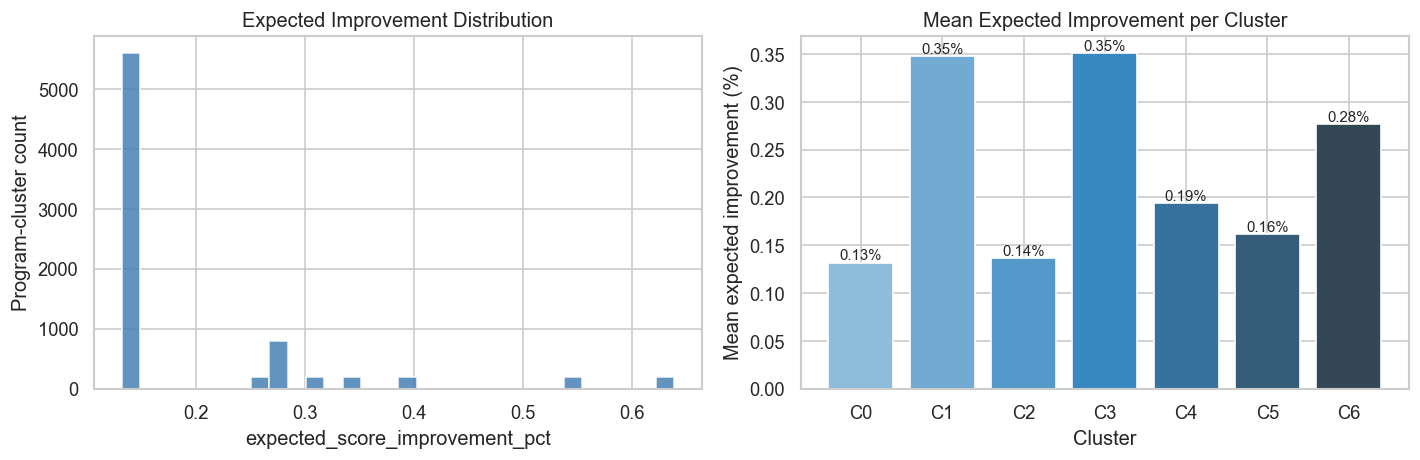

Mean expected score-improvement percent by cluster:
cluster
0    0.1317
1    0.3483
2    0.1363
3    0.3512
4    0.1938
5    0.1612
6    0.2769


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(cluster_frame[TARGET], bins=30, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_title("Expected Improvement Distribution", fontsize=12)
axes[0].set_xlabel("expected_score_improvement_pct")
axes[0].set_ylabel("Program-cluster count")

cluster_target = cluster_frame.groupby("cluster")[TARGET].mean().sort_index()
axes[1].bar([f"C{i}" for i in cluster_target.index], cluster_target.values,
            color=sns.color_palette("Blues_d", len(cluster_target)), edgecolor="white")
axes[1].set_title("Mean Expected Improvement per Cluster", fontsize=12)
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Mean expected improvement (%)")
for bar, val in zip(axes[1].patches, cluster_target.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f"{val:.2f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "prediction_improvement_target_distribution.png"), dpi=150)
plt.show()

print("Mean expected score-improvement percent by cluster:")
print(cluster_target.round(4).to_string())

## 4. Program-Level Train / Validation / Test Split

Rows are split by `program_id` so clusters from the same program cannot appear in both train and validation/test.

In [4]:
programs = cluster_frame[["program_id", TARGET]].groupby("program_id")[TARGET].max().reset_index()
program_ids = programs["program_id"].values

train_programs, temp_programs = train_test_split(
    program_ids,
    test_size=0.30,
    random_state=RANDOM_STATE,
)
val_programs, test_programs = train_test_split(
    temp_programs,
    test_size=0.50,
    random_state=RANDOM_STATE,
)

train_mask = cluster_frame["program_id"].isin(train_programs)
val_mask   = cluster_frame["program_id"].isin(val_programs)
test_mask  = cluster_frame["program_id"].isin(test_programs)

feature_drop = {
    "program_id",
    "expected_after_score",
    "expected_score_gain_points",
    TARGET,
}
feature_cols = [
    c for c in cluster_frame.select_dtypes(include=[np.number]).columns
    if c not in feature_drop
]

X = cluster_frame[feature_cols]
y = cluster_frame[TARGET].values

X_train, y_train = X.loc[train_mask], y[train_mask]
X_val, y_val     = X.loc[val_mask],   y[val_mask]
X_test, y_test   = X.loc[test_mask],  y[test_mask]
groups_train = cluster_frame.loc[train_mask, "program_id"].values

print(f"Train programs : {len(train_programs):,} | rows: {len(X_train):,}")
print(f"Val programs   : {len(val_programs):,} | rows: {len(X_val):,}")
print(f"Test programs  : {len(test_programs):,} | rows: {len(X_test):,}")
print(f"Feature count  : {len(feature_cols):,}")

for name, split_y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"{name} target mean: {split_y.mean():.4f}% | std: {split_y.std():.4f}%")

Train programs : 1,400 | rows: 5,325
Val programs   : 300 | rows: 1,143
Test programs  : 300 | rows: 1,132
Feature count  : 90
Train target mean: 0.1949% | std: 0.1177%
Val target mean: 0.1960% | std: 0.1221%
Test target mean: 0.1941% | std: 0.1112%


## 5. Evaluation Helper

In [5]:
def report_regression(y_true, y_pred, split_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*50}")
    print(f"  {split_name}")
    print(f"{'='*50}")
    print(f"  MAE  : {mae:.4f} percentage points")
    print(f"  RMSE : {rmse:.4f} percentage points")
    print(f"  R2   : {r2:.4f}")
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

## 6. XGBoost Regressor

In [6]:
n_splits = min(5, len(np.unique(groups_train)))
cv = GroupKFold(n_splits=n_splits)

xgb_base = xgb.XGBRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

cv_mae = cross_val_score(
    xgb_base, X_train, y_train, cv=cv, groups=groups_train,
    scoring="neg_mean_absolute_error", n_jobs=-1,
)
cv_r2 = cross_val_score(
    xgb_base, X_train, y_train, cv=cv, groups=groups_train,
    scoring="r2", n_jobs=-1,
)

print(f"XGB Baseline CV MAE : {-cv_mae.mean():.4f} +/- {cv_mae.std():.4f}")
print(f"XGB Baseline CV R2  : {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}")

XGB Baseline CV MAE : 0.0000 +/- 0.0000
XGB Baseline CV R2  : 1.0000 +/- 0.0000


## 7. Hyperparameter Tuning

In [7]:
xgb_param_dist = {
    "n_estimators"    : randint(100, 500),
    "max_depth"       : randint(3, 10),
    "learning_rate"   : [0.01, 0.05, 0.1, 0.2],
    "subsample"       : [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": randint(1, 10),
}

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=cv,
    scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

xgb_search.fit(X_train, y_train, groups=groups_train)
xgb_best = xgb_search.best_estimator_

print(f"Best params : {xgb_search.best_params_}")
print(f"Best CV MAE : {-xgb_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 491, 'subsample': 1.0}
Best CV MAE : 0.0000


## 8. Train vs Validation Check

In [8]:
y_pred_train_xgb = xgb_best.predict(X_train)
y_pred_val_xgb   = xgb_best.predict(X_val)

xgb_train_metrics = report_regression(y_train, y_pred_train_xgb, "XGB - Train")
xgb_val_metrics   = report_regression(y_val,   y_pred_val_xgb,   "XGB - Validation")

gap = xgb_val_metrics["MAE"] - xgb_train_metrics["MAE"]
print(f"\nMAE Gap (val - train): {gap:.4f}")


  XGB - Train
  MAE  : 0.0000 percentage points
  RMSE : 0.0000 percentage points
  R2   : 1.0000

  XGB - Validation
  MAE  : 0.0000 percentage points
  RMSE : 0.0000 percentage points
  R2   : 1.0000

MAE Gap (val - train): 0.0000


## 9. Random Forest Comparison

In [9]:
rf_param_dist = {
    "n_estimators"    : randint(100, 500),
    "max_depth"       : [None, 5, 10, 15, 20],
    "min_samples_leaf": randint(1, 10),
    "max_features"    : ["sqrt", "log2", 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=30,
    cv=cv,
    scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train, groups=groups_train)
rf_best = rf_search.best_estimator_

y_pred_val_rf = rf_best.predict(X_val)
rf_val_metrics = report_regression(y_val, y_pred_val_rf, "RF - Validation")

if xgb_val_metrics["MAE"] <= rf_val_metrics["MAE"]:
    best_model = xgb_best
    best_model_name = "XGBoost"
    best_val_metrics = xgb_val_metrics
else:
    best_model = rf_best
    best_model_name = "RandomForest"
    best_val_metrics = rf_val_metrics

print(f"Selected: {best_model_name}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/opt/homebrew/Caskroom/miniforge/base/envs/optilang/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/optilang/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/optilang/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  w


  RF - Validation
  MAE  : 0.0000 percentage points
  RMSE : 0.0000 percentage points
  R2   : 1.0000
Selected: RandomForest


## 10. Final Test Evaluation

In [10]:
y_pred_test = best_model.predict(X_test)
test_metrics = report_regression(y_test, y_pred_test, f"Test - {best_model_name}")

print(f"FINAL TEST RESULTS ({best_model_name})")
print(f"MAE  : {test_metrics['MAE']:.4f} percentage points")
print(f"RMSE : {test_metrics['RMSE']:.4f} percentage points")
print(f"R2   : {test_metrics['R2']:.4f}")


  Test - RandomForest
  MAE  : 0.0000 percentage points
  RMSE : 0.0000 percentage points
  R2   : 1.0000
FINAL TEST RESULTS (RandomForest)
MAE  : 0.0000 percentage points
RMSE : 0.0000 percentage points
R2   : 1.0000


## 11. Predicted vs Actual Plot

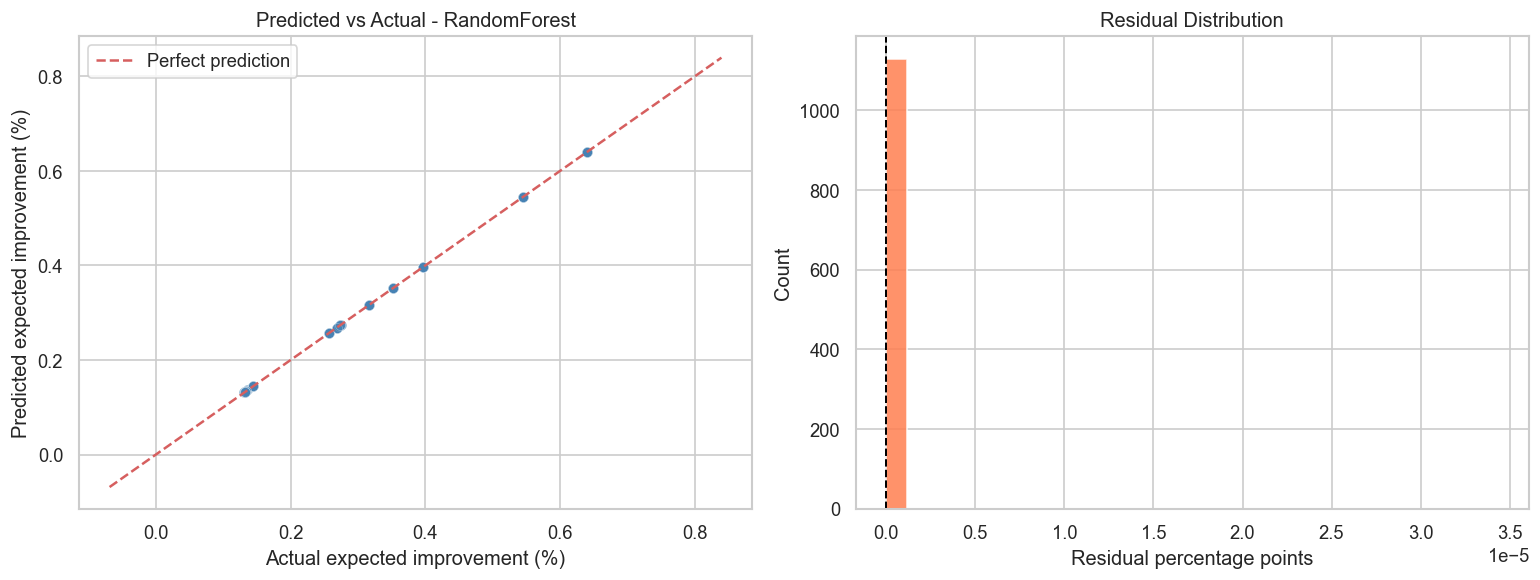

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.45, color="steelblue", edgecolors="white", linewidths=0.3)
lims = [min(y_test.min(), y_pred_test.min()) - 0.2, max(y_test.max(), y_pred_test.max()) + 0.2]
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual expected improvement (%)")
axes[0].set_ylabel("Predicted expected improvement (%)")
axes[0].set_title(f"Predicted vs Actual - {best_model_name}", fontsize=12)
axes[0].legend()

residuals = y_test - y_pred_test
axes[1].hist(residuals, bins=30, color="coral", edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Residual percentage points")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution", fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "prediction_improvement_actual_vs_predicted.png"), dpi=150)
plt.show()

## 12. Feature Importance

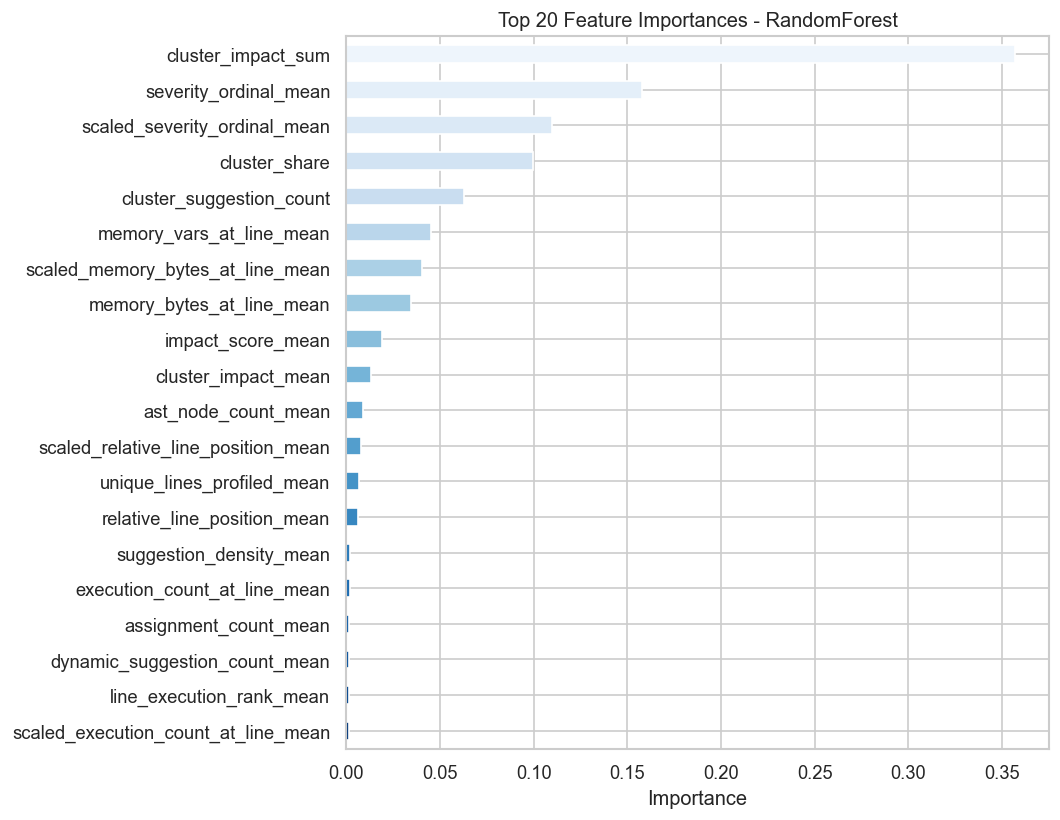

Top 10 features:
cluster_impact_sum                  0.3571
severity_ordinal_mean               0.1579
scaled_severity_ordinal_mean        0.1100
cluster_share                       0.0995
cluster_suggestion_count            0.0627
memory_vars_at_line_mean            0.0450
scaled_memory_bytes_at_line_mean    0.0403
memory_bytes_at_line_mean           0.0345
impact_score_mean                   0.0192
cluster_impact_mean                 0.0134


In [12]:
importances = best_model.feature_importances_
imp = pd.Series(importances, index=feature_cols).nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
imp.plot(kind="barh", ax=ax, color=sns.color_palette("Blues_r", len(imp)), edgecolor="white")
ax.set_title(f"Top 20 Feature Importances - {best_model_name}", fontsize=12)
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "prediction_improvement_feature_importance.png"), dpi=150)
plt.show()

print("Top 10 features:")
print(imp.tail(10).sort_values(ascending=False).round(4).to_string())

## 13. Save Model and Feature List

In [13]:
model_path = os.path.join(MODELS_DIR, f"improvement_predictor_{best_model_name.lower()}.pkl")
joblib.dump(best_model, model_path)

feature_path = os.path.join(MODELS_DIR, "improvement_predictor_features.json")
with open(feature_path, "w") as f:
    json.dump(feature_cols, f, indent=2)

target_path = os.path.join(DATA_DIR, "program_cluster_improvement.csv")
cluster_frame.to_csv(target_path, index=False)

print(f"Saved model    : {model_path}")
print(f"Saved features : {feature_path}")
print(f"Saved targets  : {target_path}")

Saved model    : /Users/stha_manik/Projects/OptiLang/optilang/optilang/ml/models/improvement_predictor_randomforest.pkl
Saved features : /Users/stha_manik/Projects/OptiLang/optilang/optilang/ml/models/improvement_predictor_features.json
Saved targets  : /Users/stha_manik/Projects/OptiLang/optilang/optilang/ml/data/program_cluster_improvement.csv


## 14. Inference Example

In [14]:
model = joblib.load(model_path)
features = json.load(open(feature_path))

example = X_test.iloc[[0]][features]
predicted_improvement = model.predict(example)[0]
actual_improvement = y_test[0]
example_meta = cluster_frame.loc[X_test.index[0], ["program_id", "cluster", "current_score", "expected_after_score"]]

print("Program-cluster example:")
print(example_meta.to_string())
print(f"Predicted expected improvement : {predicted_improvement:.4f}%")
print(f"Actual expected improvement    : {actual_improvement:.4f}%")
print(f"Error                          : {abs(predicted_improvement - actual_improvement):.4f} percentage points")

Program-cluster example:
program_id              0003_print_product_of_two_numbers.py
cluster                                                    2
current_score                                          96.95
expected_after_score                                   97.09
Predicted expected improvement : 0.1444%
Actual expected improvement    : 0.1444%
Error                          : 0.0000 percentage points
